<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/HuongDan_KNN_Bai1_DuyetVayNganHang_CoCSV_Input.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bước 1: Tạo dữ liệu mô phỏng hồ sơ vay vốn

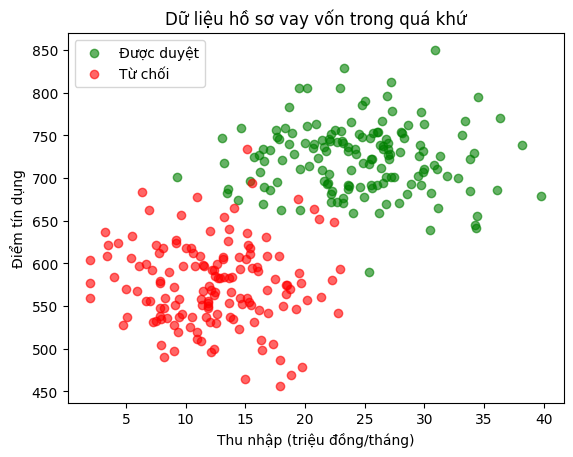

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Nhóm hồ sơ ĐƯỢC DUYỆT: thu nhập cao hơn, điểm tín dụng cao hơn
n_duyet = 150
thu_nhap_duyet = np.random.normal(25, 6, n_duyet).clip(5)  # triệu đồng/tháng
diem_tin_dung_duyet = np.random.normal(720, 40, n_duyet).clip(300, 850)

# Nhóm hồ sơ TỪ CHỐI: thu nhập thấp hơn, điểm tín dụng thấp hơn
n_tuchoi = 150
thu_nhap_tuchoi = np.random.normal(12, 5, n_tuchoi).clip(2)
diem_tin_dung_tuchoi = np.random.normal(580, 50, n_tuchoi).clip(300, 850)

thu_nhap = np.concatenate([thu_nhap_duyet, thu_nhap_tuchoi])
diem_tin_dung = np.concatenate([diem_tin_dung_duyet, diem_tin_dung_tuchoi])
ket_qua = np.concatenate([np.ones(n_duyet), np.zeros(n_tuchoi)])  # 1 = Duyệt, 0 = Từ chối

X = np.column_stack([thu_nhap, diem_tin_dung])
y = ket_qua

plt.scatter(X[y==1,0], X[y==1,1], c='green', label='Được duyệt', alpha=0.6)
plt.scatter(X[y==0,0], X[y==0,1], c='red', label='Từ chối', alpha=0.6)
plt.xlabel('Thu nhập (triệu đồng/tháng)'); plt.ylabel('Điểm tín dụng')
plt.title('Dữ liệu hồ sơ vay vốn trong quá khứ')
plt.legend()
plt.show()

Bước 2 (MỚI): Kết nối Google Drive và tạo thư mục lưu dữ liệu

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Đường dẫn thư mục trên Drive để lưu dữ liệu — có thể đổi tên tùy ý
TEN_THU_MUC = '/content/drive/MyDrive/KNN_DuLieu'
os.makedirs(TEN_THU_MUC, exist_ok=True)

print(f'Đã sẵn sàng thư mục lưu dữ liệu: {TEN_THU_MUC}')
print('Nội dung hiện có trong thư mục:', os.listdir(TEN_THU_MUC))

Mounted at /content/drive
Đã sẵn sàng thư mục lưu dữ liệu: /content/drive/MyDrive/KNN_DuLieu
Nội dung hiện có trong thư mục: []
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã sẵn sàng thư mục lưu dữ liệu: /content/drive/MyDrive/KNN_DuLieu
Nội dung hiện có trong thư mục: []


Bước 3 (MỚI): Lưu dữ liệu vào file CSV trong Google Drive

In [4]:
import pandas as pd

df = pd.DataFrame({
    'thu_nhap': thu_nhap,
    'diem_tin_dung': diem_tin_dung,
    'ket_qua': ket_qua.astype(int)
})

duong_dan_file = os.path.join(TEN_THU_MUC, 'ho_so_vay_von.csv')
df.to_csv(duong_dan_file, index=False)

print(df.head())
print(f'Đã lưu {len(df)} hồ sơ vào file: {duong_dan_file}')

    thu_nhap  diem_tin_dung  ket_qua
0  27.980285     730.019714        1
1  24.170414     733.857928        1
2  28.886131     692.799011        1
3  34.138179     729.290148        1
4  23.595080     731.722899        1
Đã lưu 300 hồ sơ vào file: /content/drive/MyDrive/KNN_DuLieu/ho_so_vay_von.csv


Bước 4: Đọc dữ liệu từ file CSV trong Drive, chia tập train/test và huấn luyện mô hình K-NN

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv(duong_dan_file)
X = df[['thu_nhap', 'diem_tin_dung']].values
y = df['ket_qua'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print('Độ chính xác với k=5:', accuracy_score(y_test, y_pred))
print('Ma trận nhầm lẫn:')
print(confusion_matrix(y_test, y_pred))

Độ chính xác với k=5: 0.9833333333333333
Ma trận nhầm lẫn:
[[29  1]
 [ 0 30]]


Bước 5: Thử nhiều giá trị k để chọn số láng giềng phù hợp

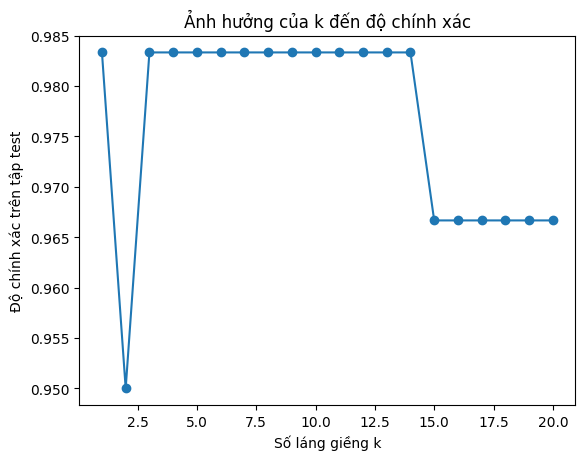

k cho độ chính xác cao nhất: 1 - Độ chính xác: 0.9833333333333333


In [6]:
do_chinh_xac = []
dai_k = range(1, 21)
for k in dai_k:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    do_chinh_xac.append(accuracy_score(y_test, m.predict(X_test)))

plt.plot(dai_k, do_chinh_xac, marker='o')
plt.xlabel('Số láng giềng k'); plt.ylabel('Độ chính xác trên tập test')
plt.title('Ảnh hưởng của k đến độ chính xác')
plt.show()

k_tot_nhat = dai_k[np.argmax(do_chinh_xac)]
print('k cho độ chính xác cao nhất:', k_tot_nhat, '- Độ chính xác:', max(do_chinh_xac))

Bước 6: Trực quan hóa ranh giới quyết định (Decision Boundary)

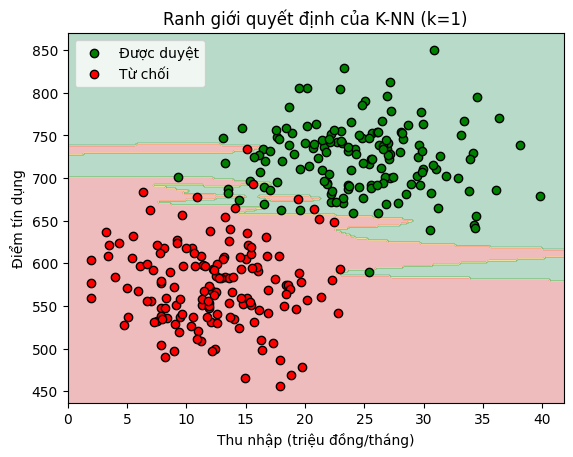

In [7]:
knn_final = KNeighborsClassifier(n_neighbors=k_tot_nhat).fit(X_train, y_train)

x_min, x_max = X[:,0].min() - 2, X[:,0].max() + 2
y_min, y_max = X[:,1].min() - 20, X[:,1].max() + 20
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = knn_final.predict(np.column_stack([xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.scatter(X[y==1,0], X[y==1,1], c='green', label='Được duyệt', edgecolors='k')
plt.scatter(X[y==0,0], X[y==0,1], c='red', label='Từ chối', edgecolors='k')
plt.xlabel('Thu nhập (triệu đồng/tháng)'); plt.ylabel('Điểm tín dụng')
plt.title(f'Ranh giới quyết định của K-NN (k={k_tot_nhat})')
plt.legend()
plt.show()

Bước 7 (MỚI): Dự đoán cho một hồ sơ vay vốn mới do người dùng nhập vào

In [8]:
print('=== DỰ ĐOÁN DUYỆT HỒ SƠ VAY VỐN MỚI ===')
print("(Nhập 'q' ở bước nhập thu nhập để dừng)")

while True:
    nhap = input('\nNhập thu nhập (triệu đồng/tháng) — hoặc q để dừng: ')
    if nhap.strip().lower() == 'q':
        break
    thu_nhap_moi = float(nhap)
    diem_tin_dung_moi = float(input('Nhập điểm tín dụng (300-850): '))

    ho_so_moi = np.array([[thu_nhap_moi, diem_tin_dung_moi]])
    du_doan = knn_final.predict(ho_so_moi)[0]
    xac_suat = knn_final.predict_proba(ho_so_moi)[0]

    nhan = 'ĐƯỢC DUYỆT' if du_doan == 1 else 'TỪ CHỐI'
    print(f'=> Kết quả dự đoán: {nhan}')
    print(f'   (Xác suất Từ chối: {xac_suat[0]*100:.1f}%  |  Được duyệt: {xac_suat[1]*100:.1f}%)')

=== DỰ ĐOÁN DUYỆT HỒ SƠ VAY VỐN MỚI ===
(Nhập 'q' ở bước nhập thu nhập để dừng)

Nhập thu nhập (triệu đồng/tháng) — hoặc q để dừng: 50000000
Nhập điểm tín dụng (300-850): 350
=> Kết quả dự đoán: ĐƯỢC DUYỆT
   (Xác suất Từ chối: 0.0%  |  Được duyệt: 100.0%)

Nhập thu nhập (triệu đồng/tháng) — hoặc q để dừng: q


Bài tập mở rộng

Thử lại toàn bộ quy trình với k=1 và k=19 (hai giá trị cực đoan), quan sát ranh giới quyết định thay đổi thế nào.

Độ chính xác với k=1: 0.9833333333333333


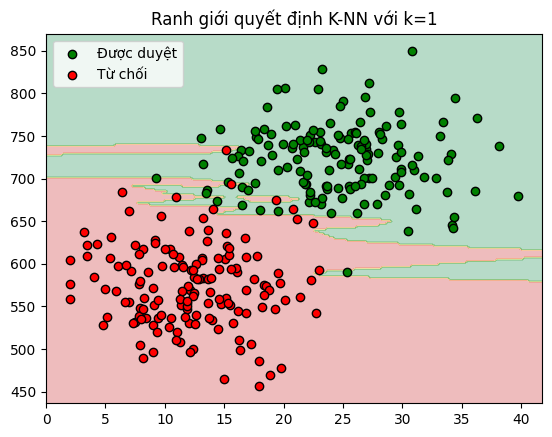

Độ chính xác với k=19: 0.9666666666666667


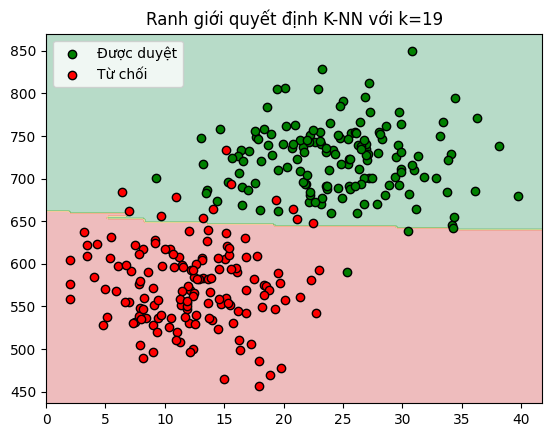

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# k=1
knn1 = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)
y_pred1 = knn1.predict(X_test)
print("Độ chính xác với k=1:", accuracy_score(y_test, y_pred1))

# Vẽ ranh giới quyết định cho k=1
x_min, x_max = X[:,0].min() - 2, X[:,0].max() + 2
y_min, y_max = X[:,1].min() - 20, X[:,1].max() + 20
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z1 = knn1.predict(np.column_stack([xx.ravel(), yy.ravel()]))
Z1 = Z1.reshape(xx.shape)

plt.contourf(xx, yy, Z1, alpha=0.3, cmap='RdYlGn')
plt.scatter(X[y==1,0], X[y==1,1], c='green', label='Được duyệt', edgecolors='k')
plt.scatter(X[y==0,0], X[y==0,1], c='red', label='Từ chối', edgecolors='k')
plt.title("Ranh giới quyết định K-NN với k=1")
plt.legend()
plt.show()

# k=19
knn19 = KNeighborsClassifier(n_neighbors=19).fit(X_train, y_train)
y_pred19 = knn19.predict(X_test)
print("Độ chính xác với k=19:", accuracy_score(y_test, y_pred19))

Z19 = knn19.predict(np.column_stack([xx.ravel(), yy.ravel()]))
Z19 = Z19.reshape(xx.shape)

plt.contourf(xx, yy, Z19, alpha=0.3, cmap='RdYlGn')
plt.scatter(X[y==1,0], X[y==1,1], c='green', label='Được duyệt', edgecolors='k')
plt.scatter(X[y==0,0], X[y==0,1], c='red', label='Từ chối', edgecolors='k')
plt.title("Ranh giới quyết định K-NN với k=19")
plt.legend()
plt.show()


Thêm đặc trưng thứ 3 (ví dụ: số năm kinh nghiệm làm việc) và thử áp dụng K-NN với 3 đặc trưng (lưu ý: khi đó không thể vẽ ranh giới quyết định 2D).

Thêm đặc trưng thứ 3 (ví dụ: số năm kinh nghiệm làm việc)  

In [11]:
# Giả lập số năm kinh nghiệm cho 2 nhóm
kinh_nghiem_duyet = np.random.normal(10, 3, n_duyet).clip(0)   # nhóm được duyệt
kinh_nghiem_tuchoi = np.random.normal(3, 2, n_tuchoi).clip(0)  # nhóm từ chối

# Ghép thêm vào ma trận X
X3 = np.column_stack([thu_nhap, diem_tin_dung,
                      np.concatenate([kinh_nghiem_duyet, kinh_nghiem_tuchoi])])


Huấn luyện K-NN với 3 đặc trưng

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y, test_size=0.2, random_state=42, stratify=y)

knn3 = KNeighborsClassifier(n_neighbors=5)
knn3.fit(X_train3, y_train3)
y_pred3 = knn3.predict(X_test3)

print("Độ chính xác với 3 đặc trưng:", accuracy_score(y_test3, y_pred3))


Độ chính xác với 3 đặc trưng: 0.9833333333333333


Thử chuẩn hóa dữ liệu bằng StandardScaler trước khi huấn luyện K-NN, so sánh độ chính xác trước/sau chuẩn hóa

Huấn luyện K-NN với dữ liệu gốc (chưa chuẩn hóa)

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Huấn luyện KNN với k=5
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)

print("Độ chính xác trước chuẩn hóa:", accuracy_score(y_test, y_pred_raw))


Độ chính xác trước chuẩn hóa: 0.9833333333333333


Chuẩn hóa dữ liệu bằng StandardScaler và huấn luyện lại

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train_s)
y_pred_scaled = knn_scaled.predict(X_test_s)

print("Độ chính xác sau chuẩn hóa:", accuracy_score(y_test_s, y_pred_scaled))


Độ chính xác sau chuẩn hóa: 0.9666666666666667
